# 04 · Proteomics — rapamycin remodels the proteome of lymphoma cells

**Data:** PXD067812 — human DLBCL line **SU-DHL-4** treated with rapamycin (24 h, 48 h)
vs DMSO, TMT-18plex quantitative proteomics (mzTab). We test **rapamycin (n=6) vs
DMSO (n=3)** at the protein level and ask whether translation machinery / mTOR effectors
fall, mirroring the transcriptome.

In [1]:
import os, sys, json, gzip, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

# Resolve project root whether run from notebooks/ or project root.
CWD = Path.cwd()
PROJ = CWD.parent if CWD.name == "notebooks" else CWD
RAW = PROJ / "data" / "raw"
PROC = PROJ / "data" / "processed"
FIG = PROJ / "figures"
for d in (RAW, PROC, FIG):
    d.mkdir(parents=True, exist_ok=True)

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")
print("Project root:", PROJ)

Project root: /Users/jinmo/Documents/GitHub/Series1/Jin001_Docking/rapamycin_multiomics


## 1 · Parse the mzTab protein-quantification table

In [2]:
mztab = RAW/"PXD067812.mzTab"
# Read PRH (header) + PRT (protein) lines.
prh, prt = None, []
with open(mztab) as fh:
    for line in fh:
        if line.startswith("PRH"):
            prh = line.rstrip("\n").split("\t")
        elif line.startswith("PRT"):
            prt.append(line.rstrip("\n").split("\t"))
prot = pd.DataFrame(prt, columns=prh)
print("Protein rows:", prot.shape[0])

cmap = pd.read_csv(PROC/"proteomics_channel_map.csv")  # assay -> condition/sample
abund_cols = {row.assay: f"protein_abundance_assay[{row.assay}]" for _, row in cmap.iterrows()}
keep = ["accession","description"] + [abund_cols[a] for a in cmap.assay if abund_cols[a] in prot.columns]
prot = prot[keep].copy()
prot.columns = ["accession","description"] + list(cmap["sample"])
for s in cmap["sample"]:
    prot[s] = pd.to_numeric(prot[s], errors="coerce")
prot.head(3)

Protein rows: 6817


,accession,description,DMSO_1,DMSO_2,DMSO_3,Rapa24h_1,Rapa24h_2,Rapa24h_3,Rapa48h_1,Rapa48h_2,Rapa48h_3,MasterMix
0,P78527,DNA-dependent protein kinase catalytic subunit...,282115.9,324634.7,313809.6,314767.6,230979.8,329197.4,290207.2,261042.9,255814.3,288446.9
1,Q14204,Cytoplasmic dynein 1 heavy chain 1 OS=Homo sap...,188575.2,219361.2,213212.9,222469.3,162883.6,229531.4,203701.5,179079.3,182395.9,200104.8
2,Q15149,Plectin OS=Homo sapiens OX=9606 GN=PLEC PE=1 SV=3,149392.1,169947.3,167583.1,156567.4,116508.3,160586.1,136942.8,118999.8,120899.3,142127.6


In [3]:
# Gene symbol from description (UniProt 'GN=' tag) or accession.
def gene_from_desc(d):
    m = re.search(r"GN=([A-Za-z0-9_.-]+)", str(d))
    return m.group(1).upper() if m else None
prot["symbol"] = prot["description"].apply(gene_from_desc)
samples = list(cmap["sample"])
dmso = [s for s in samples if s.startswith("DMSO")]
rapa = [s for s in samples if s.startswith("Rapa")]
print("DMSO channels:", dmso); print("Rapamycin channels:", rapa)

# Keep proteins quantified in all analysed channels; drop master mix.
quant = prot.dropna(subset=dmso+rapa).copy()
print("Quantified proteins:", quant.shape[0])

DMSO channels: ['DMSO_1', 'DMSO_2', 'DMSO_3']
Rapamycin channels: ['Rapa24h_1', 'Rapa24h_2', 'Rapa24h_3', 'Rapa48h_1', 'Rapa48h_2', 'Rapa48h_3']
Quantified proteins: 6612


## 2 · Normalise (log2 + median-centre per channel)

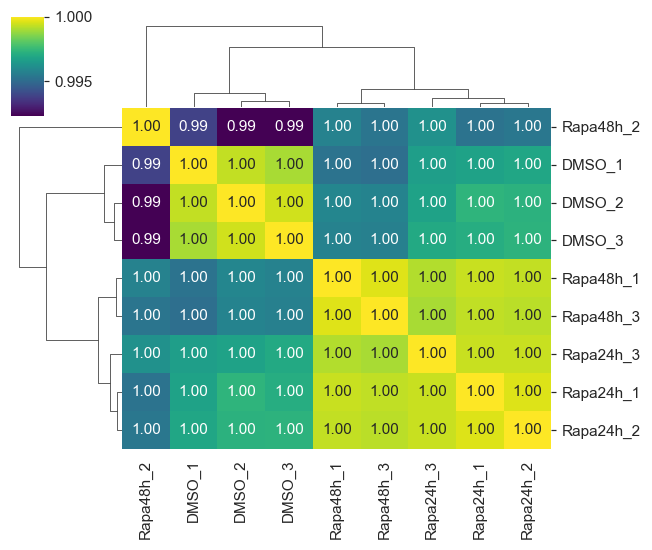

In [4]:
mat = np.log2(quant[dmso+rapa].astype(float) + 1)
mat = mat - mat.median(axis=0)        # column (channel) median centring
quant[dmso+rapa] = mat.values

# Sample correlation / clustering sanity check
import scipy.cluster.hierarchy as h
corr = mat.corr()
sns.clustermap(corr, cmap="viridis", figsize=(6,5), annot=True, fmt=".2f")
plt.savefig(FIG/"04_sample_corr.png", dpi=150); plt.show()

## 3 · Differential abundance: rapamycin vs DMSO

In [5]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
R = quant[rapa].values; D = quant[dmso].values
log2fc = R.mean(axis=1) - D.mean(axis=1)
pvals = np.array([stats.ttest_ind(R[i], D[i], equal_var=False).pvalue for i in range(len(quant))])
pde = quant[["accession","symbol","description"]].copy()
pde["log2FC"] = log2fc
pde["pval"] = np.nan_to_num(pvals, nan=1.0)
pde["padj"] = multipletests(pde["pval"], method="fdr_bh")[1]
pde = pde.sort_values("pval")
pde.to_csv(PROC/"proteomics_DE_rapamycin_vs_dmso.csv", index=False)
print("Proteins down (log2FC<-0.3, p<0.05):", ((pde.log2FC<-0.3)&(pde.pval<0.05)).sum())
print("Proteins up   (log2FC>0.3, p<0.05):", ((pde.log2FC>0.3)&(pde.pval<0.05)).sum())
pde.head(12)[["symbol","log2FC","pval","padj"]]

Proteins down (log2FC<-0.3, p<0.05): 365
Proteins up   (log2FC>0.3, p<0.05): 248


,symbol,log2FC,pval,padj
3503,PTTG1,-0.365691,2.754444e-10,0.000002
971,PUM3,-0.411832,6.484768e-10,0.000002
322,HLTF,-0.534066,1.687724e-09,0.000004
6231,SFT2D3,-0.688291,2.331222e-09,0.000004
1081,UTP4,-0.442316,2.815043e-09,0.000004
6067,RAD54B,-0.384135,4.360393e-09,0.000005
1023,RPLP0,-0.184601,6.203625e-09,0.000005
559,EIF3E,-0.279844,6.802450e-09,0.000005
451,HECTD1,-0.373410,7.115238e-09,0.000005
2976,PAWR,-0.498771,8.378423e-09,0.000006


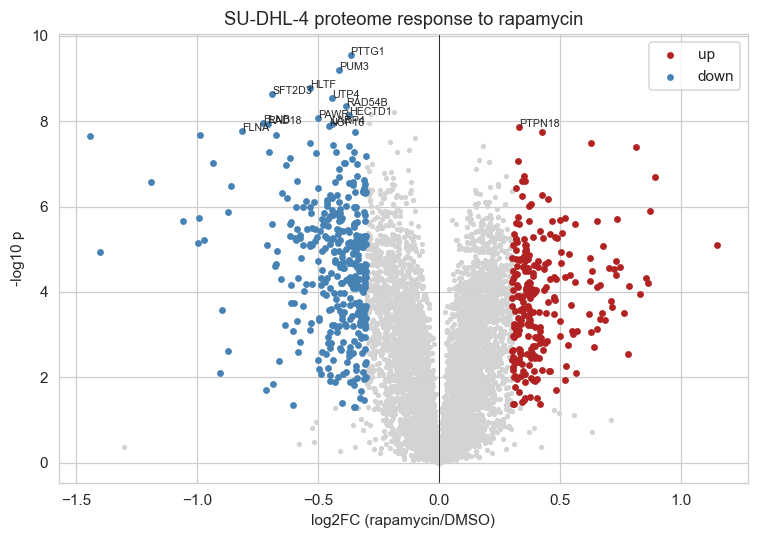

In [6]:
fig, ax = plt.subplots(figsize=(7,5))
x = pde["log2FC"]; y = -np.log10(pde["pval"].clip(lower=1e-300))
sig = (pde.pval<0.05) & (pde.log2FC.abs()>0.3)
ax.scatter(x[~sig], y[~sig], s=6, c="lightgrey")
ax.scatter(x[sig&(x>0)], y[sig&(x>0)], s=12, c="firebrick", label="up")
ax.scatter(x[sig&(x<0)], y[sig&(x<0)], s=12, c="steelblue", label="down")
for _, r in pde[sig].head(14).iterrows():
    if r["symbol"]:
        ax.annotate(r["symbol"], (r["log2FC"], -np.log10(max(r["pval"],1e-300))), fontsize=7)
ax.axvline(0,c="k",lw=.5); ax.set_xlabel("log2FC (rapamycin/DMSO)"); ax.set_ylabel("-log10 p")
ax.set_title("SU-DHL-4 proteome response to rapamycin"); ax.legend()
plt.tight_layout(); plt.savefig(FIG/"04_volcano.png", dpi=150); plt.show()

## 4 · Pathway enrichment + mTOR / translation effectors

In [7]:
import gseapy as gp
dn = pde[(pde.pval<0.05)&(pde.log2FC<-0.3)]["symbol"].dropna().unique().tolist()
up = pde[(pde.pval<0.05)&(pde.log2FC>0.3)]["symbol"].dropna().unique().tolist()
try:
    e = gp.enrichr(gene_list=dn, organism="human",
                   gene_sets=["KEGG_2021_Human","Reactome_2022"], outdir=None, no_plot=True).results
    print("Top pathways DOWN under rapamycin:")
    display(e.sort_values("Adjusted P-value").head(10)[["Gene_set","Term","Adjusted P-value","Overlap"]])
except Exception as ex:
    print("Enrichr error:", ex)

Enrichr error: 'DataFrame' object has no attribute 'append'


mTOR/translation proteins detected: 112


,symbol,log2FC,pval
5384,RPL10L,-0.572375,1.452112e-03
204,EIF4B,-0.341721,4.577186e-06
4102,RPS28,-0.323814,2.059945e-02
5631,SREBF1,-0.322103,4.067706e-04
2362,RPL34,-0.298864,7.087426e-03
3649,RPL22L1,-0.292271,2.553472e-03
2357,RPL35A,-0.267198,3.343573e-03
1258,SQSTM1,-0.262868,1.323341e-04
2122,RPL23A,-0.249040,4.503551e-03
39,EIF4G1,-0.245455,3.294778e-05


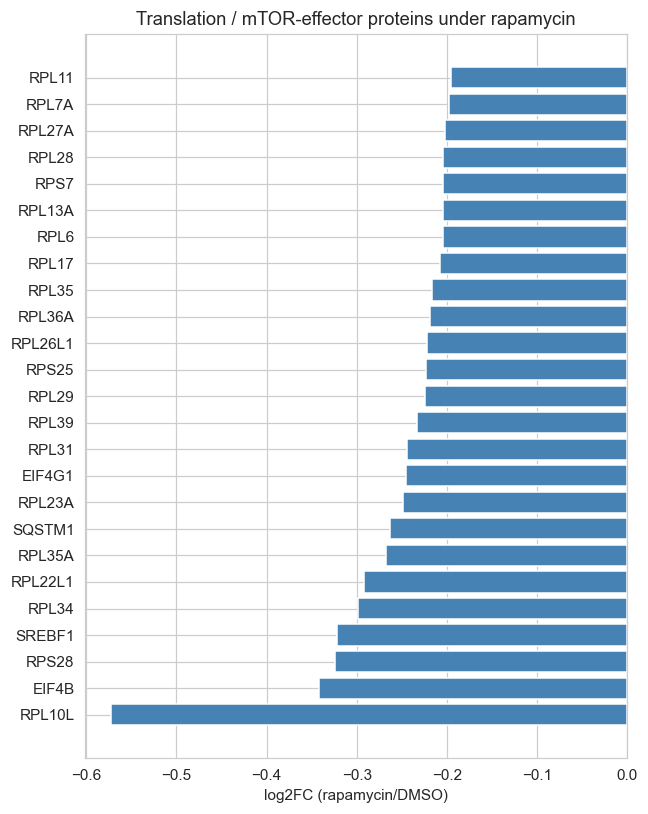

In [8]:
mtor = pd.read_csv(PROC/"mtor_pathway_genes.csv")["gene"].str.upper().tolist()
# Also include the ribosomal-protein family as a translation readout.
hit = pde[pde["symbol"].isin(mtor) | pde["symbol"].str.match(r"^RP[SL]\d", na=False)].copy()
hit = hit.dropna(subset=["symbol"]).sort_values("log2FC")
print("mTOR/translation proteins detected:", len(hit))
display(hit[["symbol","log2FC","pval"]].head(25))
if len(hit):
    sub = hit.head(25)
    fig, ax = plt.subplots(figsize=(6, max(3,.3*len(sub))))
    ax.barh(sub["symbol"], sub["log2FC"],
            color=["steelblue" if v<0 else "firebrick" for v in sub["log2FC"]])
    ax.axvline(0,c="k",lw=.6); ax.set_xlabel("log2FC (rapamycin/DMSO)")
    ax.set_title("Translation / mTOR-effector proteins under rapamycin")
    plt.tight_layout(); plt.savefig(FIG/"04_mtor_proteins.png", dpi=150); plt.show()

**Takeaway.** At the protein level rapamycin suppresses translation machinery / mTORC1
effectors in lymphoma cells — independent confirmation, in human cancer cells, of the
mechanism inferred transcriptionally. Saved to
`data/processed/proteomics_DE_rapamycin_vs_dmso.csv`.